In [1]:
import os
import random
import cv2
import tensorflow as tf
from tensorflow import keras
from keras import layers,models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn import metrics
import zipfile
import shutil

In [2]:
from google.colab import files

uploaded = files.upload()

Saving lung_subset_small_folder.zip to lung_subset_small_folder.zip


In [3]:
print("Files currently in Colab:")
print(os.listdir("/content"))
zip_files = [f for f in os.listdir("/content") if f.lower().endswith(".zip")]

print("ZIP files found:")
for f in zip_files:
    print(f)

Files currently in Colab:
['.config', 'lung_subset_small_folder.zip', 'sample_data']
ZIP files found:
lung_subset_small_folder.zip


In [4]:
zip_path = "/content/" + zip_files[0]

print("Checking:", zip_path)

if zipfile.is_zipfile(zip_path):
    print("Valid ZIP file!")
else:
    print("This is NOT a valid ZIP file.")

Checking: /content/lung_subset_small_folder.zip
Valid ZIP file!


In [5]:
extract_path = "/content/lung_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [6]:
print("Extracted contents:\n")

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent} {os.path.basename(root)}/")

    for file in files[:5]:
        print(f"{indent}    📄 {file}")

    if len(files) > 5:
        print(f"{indent}    ... and {len(files)-5} more files")

Extracted contents:

 lung_dataset/
     lung_subset_small/
         lung_n/
            📄 lungn2576.jpeg
            📄 lungn1214.jpeg
            📄 lungn4889.jpeg
            📄 lungn3590.jpeg
            📄 lungn4240.jpeg
            ... and 795 more files
         lung_scc/
            📄 lungscc1619.jpeg
            📄 lungscc2236.jpeg
            📄 lungscc3310.jpeg
            📄 lungscc1173.jpeg
            📄 lungscc1454.jpeg
            ... and 795 more files
         lung_aca/
            📄 lungaca1305.jpeg
            📄 lungaca1601.jpeg
            📄 lungaca738.jpeg
            📄 lungaca2927.jpeg
            📄 lungaca85.jpeg
            ... and 795 more files


In [7]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")
class_dirs = []

for root, dirs, files in os.walk(extract_path):
    image_files = [
        f for f in files
        if f.lower().endswith(image_extensions)
    ]

    if image_files:
        class_dirs.append(root)

print("Class folders found:\n")

for folder in class_dirs:
    print(folder)

path = os.path.dirname(class_dirs[0])

classes = [
    os.path.basename(folder)
    for folder in class_dirs
]

print("\nPath:", path)
print("Classes:", classes)

Class folders found:

/content/lung_dataset/lung_subset_small/lung_n
/content/lung_dataset/lung_subset_small/lung_scc
/content/lung_dataset/lung_subset_small/lung_aca

Path: /content/lung_dataset/lung_subset_small
Classes: ['lung_n', 'lung_scc', 'lung_aca']


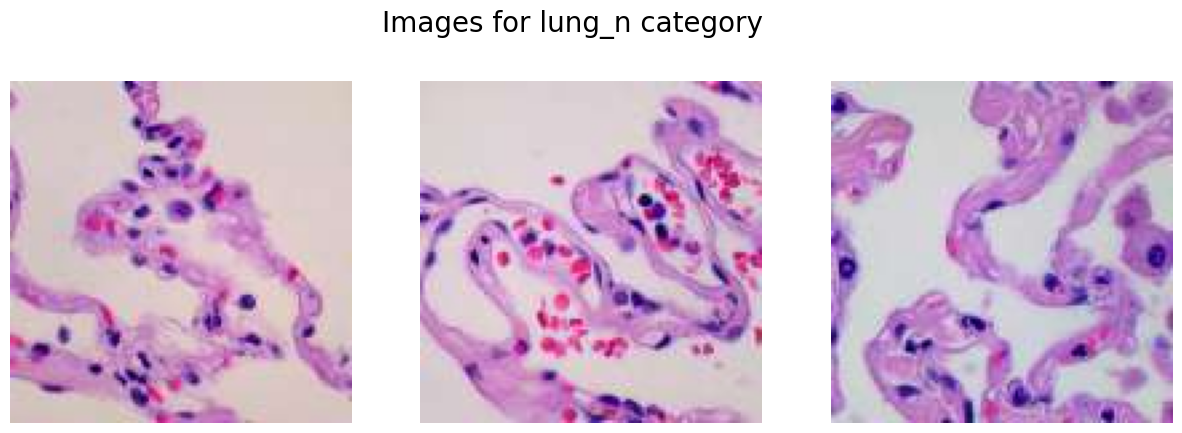

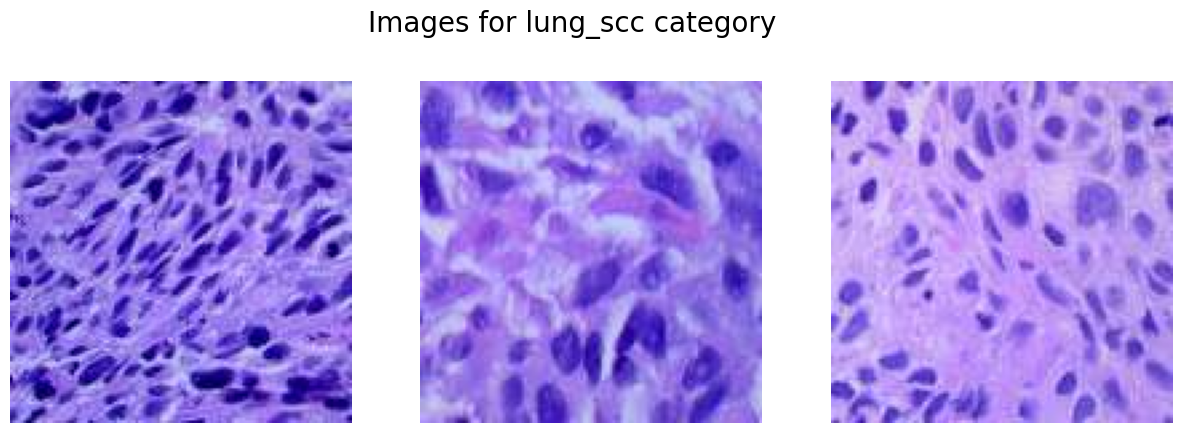

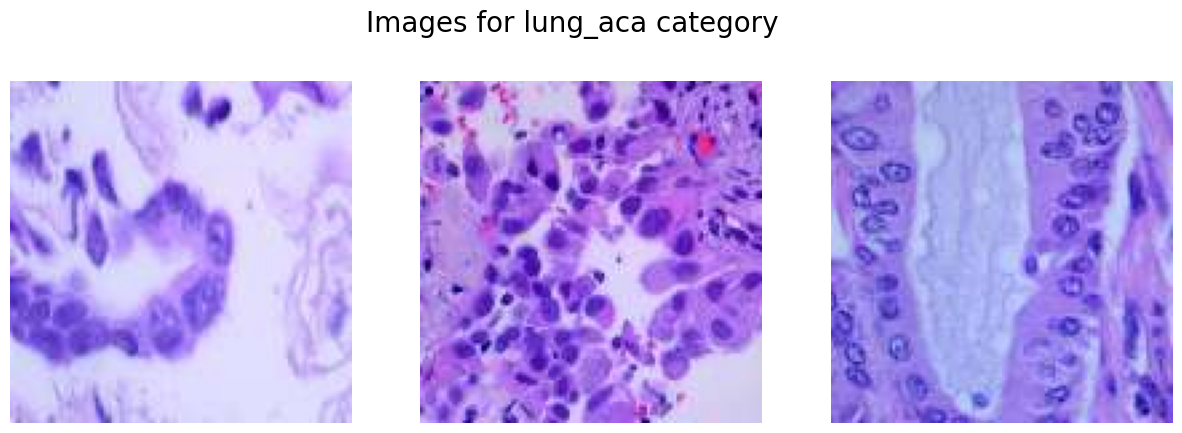

In [8]:
for cat in classes:

    image_dir = os.path.join(path, cat)

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    fig.suptitle(
        f"Images for {cat} category",
        fontsize=20
    )

    for i in range(3):

        k = np.random.randint(0, len(images))

        image_path = os.path.join(image_dir, images[k])

        img = np.array(Image.open(image_path))

        ax[i].imshow(img)
        ax[i].axis("off")

    plt.show()

In [9]:
print("Dataset path:", path)
print("\nClasses:")

for cat in classes:
    image_dir = os.path.join(path, cat)
    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    print(f"{cat}: {len(images)} images")

Dataset path: /content/lung_dataset/lung_subset_small

Classes:
lung_n: 800 images
lung_scc: 800 images
lung_aca: 800 images


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.30
)

# Training set
train_data = train_datagen.flow_from_directory(
    path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Validation set
val_data = train_datagen.flow_from_directory(
    path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print("\nClass indices:")
print(train_data.class_indices)

print("\nTraining images:", train_data.samples)
print("Validation images:", val_data.samples)

Found 1680 images belonging to 3 classes.
Found 720 images belonging to 3 classes.

Class indices:
{'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}

Training images: 1680
Validation images: 720


In [11]:
random.seed(42)

source_path = path
split_path = "/content/dataset_split"

# Create folders
for split in ["train", "validation", "test"]:
    for cat in classes:
        os.makedirs(
            os.path.join(split_path, split, cat),
            exist_ok=True
        )

# Split each class
for cat in classes:

    class_path = os.path.join(source_path, cat)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    random.shuffle(images)

    total = len(images)

    train_end = int(0.70 * total)
    val_end = int(0.85 * total)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for img in train_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(split_path, "train", cat, img)
        )

    for img in val_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(split_path, "validation", cat, img)
        )

    for img in test_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(split_path, "test", cat, img)
        )

print("Dataset split completed!")

for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}:")

    for cat in classes:
        folder = os.path.join(split_path, split, cat)
        print(f"{cat}: {len(os.listdir(folder))}")

Dataset split completed!

TRAIN:
lung_n: 560
lung_scc: 560
lung_aca: 560

VALIDATION:
lung_n: 120
lung_scc: 120
lung_aca: 120

TEST:
lung_n: 120
lung_scc: 120
lung_aca: 120


In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation & test: ONLY rescaling
test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Training data
train_data = train_datagen.flow_from_directory(
    "/content/dataset_split/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

# Validation data
val_data = test_datagen.flow_from_directory(
    "/content/dataset_split/validation",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Test data
test_data = test_datagen.flow_from_directory(
    "/content/dataset_split/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nClass indices:")
print(train_data.class_indices)

print("\nDataset sizes:")
print("Training:", train_data.samples)
print("Validation:", val_data.samples)
print("Testing:", test_data.samples)

Found 1680 images belonging to 3 classes.
Found 360 images belonging to 3 classes.
Found 360 images belonging to 3 classes.

Class indices:
{'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}

Dataset sizes:
Training: 1680
Validation: 360
Testing: 360


In [13]:
model = models.Sequential([

    # Input
    layers.Input(shape=(224, 224, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output: 3 classes
    layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,523 (19.48 MB)

 Trainable params: 5,107,523 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.layers import Dense
Dense(3, activation='softmax')

<Dense name=dense_2, built=False>

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/content/best_lung_cancer_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 282s 5s/step - accuracy: 0.6970 - loss: 0.5804 - val_accuracy: 0.8667 - val_loss: 0.3779
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 299s 6s/step - accuracy: 0.8274 - loss: 0.4140 - val_accuracy: 0.8528 - val_loss: 0.4179
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 317s 6s/step - accuracy: 0.8518 - loss: 0.3922 - val_accuracy: 0.8722 - val_loss: 0.3582
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 292s 6s/step - accuracy: 0.8679 - loss: 0.3417 - val_accuracy: 0.8306 - val_loss: 0.4289
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 280s 5s/step - accuracy: 0.8863 - loss: 0.3100 - val_accuracy: 0.8583 - val_loss: 0.3120
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 294s 6s/step - accuracy: 0.8935 - loss: 0.3024 - val_accuracy: 0.8333 - val_loss: 0.4294
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 279s 5s/step - accuracy: 0.8667 - loss: 0.3446 - val_accuracy: 0.8778 - val_loss: 0.2987
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 294s 6s/step - accuracy: 0.8911 - loss: 0.2940 - val_accuracy: 0.8889 - v

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

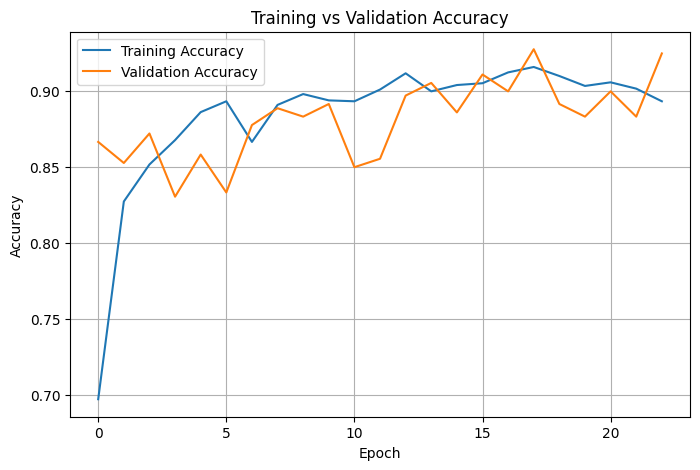

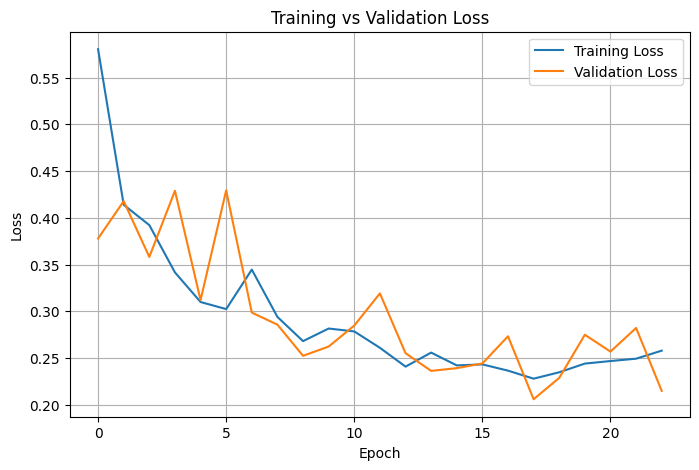

In [19]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()


# Loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [20]:
# Reset test generator
test_data.reset()

# Get predictions
pred_probs = model.predict(test_data)

# Convert probabilities to class labels
y_pred = np.argmax(pred_probs, axis=1)

# Actual labels
y_true = test_data.classes

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))
print("Number of actual labels:", len(y_true))

12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step
Predictions generated successfully!
Number of predictions: 360
Number of actual labels: 360


In [22]:
from sklearn.metrics import classification_report

# Get class names
class_names = list(train_data.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

              precision    recall  f1-score   support

    lung_aca     0.9060    0.8833    0.8945       120
      lung_n     1.0000    0.9833    0.9916       120
    lung_scc     0.8880    0.9250    0.9061       120

    accuracy                         0.9306       360
   macro avg     0.9313    0.9306    0.9307       360
weighted avg     0.9313    0.9306    0.9307       360



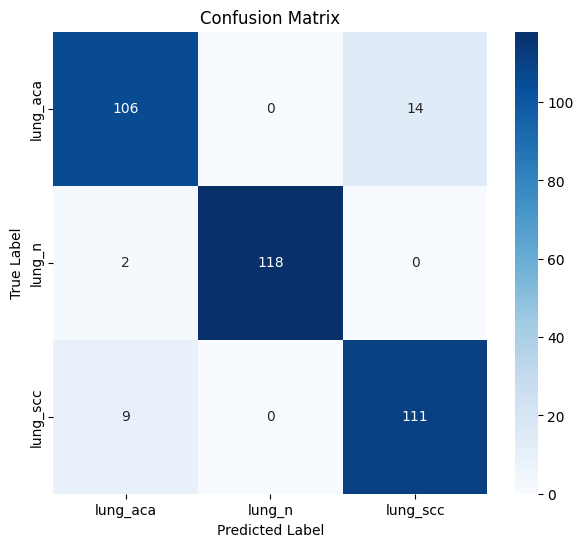

In [25]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Total test images: 360
Misclassified images: 25
Misclassification rate: 6.94%


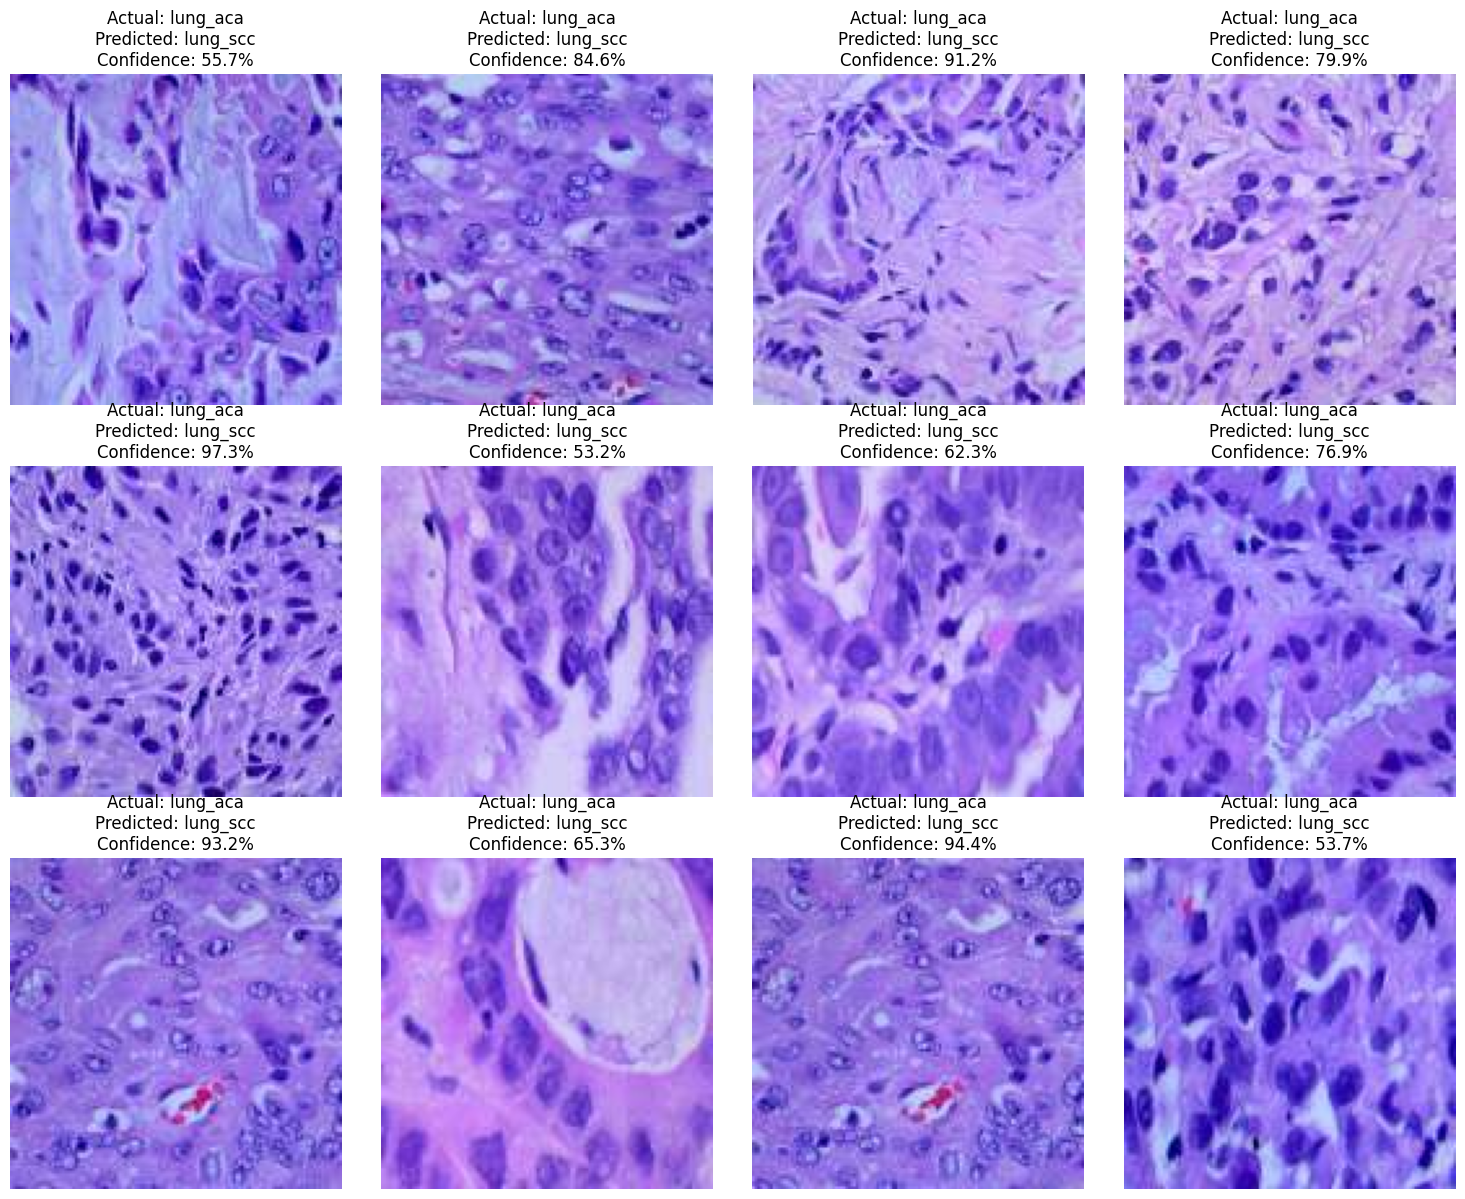

In [26]:
# Find incorrect predictions
wrong_indices = np.where(y_true != y_pred)[0]

print("Total test images:", len(y_true))
print("Misclassified images:", len(wrong_indices))
print("Misclassification rate:",
      f"{len(wrong_indices) / len(y_true) * 100:.2f}%")

# Show up to 12 wrong predictions
num_images = min(12, len(wrong_indices))

plt.figure(figsize=(15, 12))

for i in range(num_images):

    idx = wrong_indices[i]

    # Get image path from test generator
    image_path = test_data.filepaths[idx]

    img = Image.open(image_path)

    actual = class_names[y_true[idx]]
    predicted = class_names[y_pred[idx]]
    confidence = np.max(pred_probs[idx]) * 100

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
cm = confusion_matrix(y_true, y_pred)

print("Misclassifications by actual class:\n")

for i, cls in enumerate(class_names):
    incorrect = np.sum(cm[i]) - cm[i, i]
    print(f"{cls}: {incorrect} misclassified")

print("\nMisclassifications by predicted class:\n")

for i, cls in enumerate(class_names):
    incorrect = np.sum(cm[:, i]) - cm[i, i]
    print(f"{cls}: {incorrect} incorrectly predicted")

Misclassifications by actual class:

lung_aca: 14 misclassified
lung_n: 2 misclassified
lung_scc: 9 misclassified

Misclassifications by predicted class:

lung_aca: 11 incorrectly predicted
lung_n: 0 incorrectly predicted
lung_scc: 14 incorrectly predicted


In [28]:
for layer in model.layers:
    print(layer.name, layer.__class__.__name__)

conv2d Conv2D
max_pooling2d MaxPooling2D
conv2d_1 Conv2D
max_pooling2d_1 MaxPooling2D
conv2d_2 Conv2D
max_pooling2d_2 MaxPooling2D
conv2d_3 Conv2D
max_pooling2d_3 MaxPooling2D
flatten Flatten
dense Dense
dropout Dropout
dense_1 Dense


In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Make sure the model has been called once
_ = model.predict(
    np.zeros((1, 224, 224, 3), dtype=np.float32),
    verbose=0
)

# Get the last convolutional layer
last_conv_layer = model.get_layer("conv2d_3")

# Build Grad-CAM model
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        last_conv_layer.output,
        model.layers[-1].output
    ]
)

print("Grad-CAM model created successfully!")

Grad-CAM model created successfully!


In [34]:
def make_gradcam(image_path):

    # Load image
    img = Image.open(image_path).convert("RGB")
    img = img.resize((224, 224))

    # Preprocess
    img_array = np.array(img).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Gradient calculation
    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        predicted_class = tf.argmax(predictions[0])
        predicted_score = predictions[0][predicted_class]

    # Gradients
    gradients = tape.gradient(
        predicted_score,
        conv_outputs
    )

    # Average gradients
    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    # Feature maps
    conv_outputs = conv_outputs[0]

    # Weighted feature maps
    heatmap = conv_outputs @ pooled_gradients[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # Remove negative values
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap /= max_value

    return (
        img,
        heatmap.numpy(),
        predicted_class.numpy(),
        predicted_score.numpy()
    )

In [35]:
test_image = test_data.filepaths[0]

img, heatmap, predicted_class, confidence = make_gradcam(
    test_image
)

predicted_label = class_names[predicted_class]

print("Predicted class:", predicted_label)
print("Confidence:", f"{confidence * 100:.2f}%")

Predicted class: lung_aca
Confidence: 98.61%


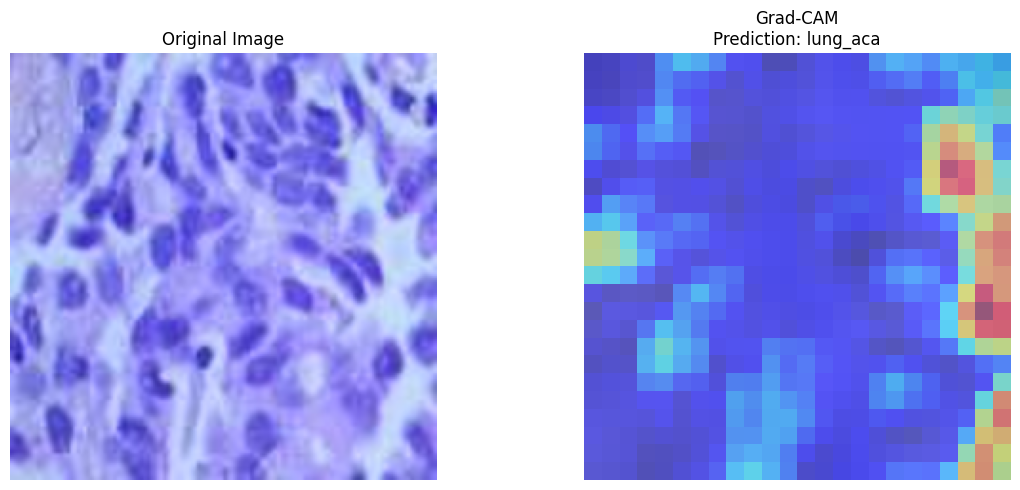

In [36]:
plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Grad-CAM
plt.subplot(1, 2, 2)
plt.imshow(img)
plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.5
)
plt.title(
    f"Grad-CAM\nPrediction: {predicted_label}"
)
plt.axis("off")

plt.tight_layout()
plt.show()